# Implement Test of Multitask Multivariate Truncated Normal Likelihood

In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import torch
import gpytorch
from gpytorch.likelihoods import Likelihood, MultitaskGaussianLikelihood
from botorch.utils.probability.truncated_multivariate_normal import TruncatedMultivariateNormal
from torch.distributions import constraints
from gpytorch.constraints import GreaterThan
from gpytorch.distributions import MultivariateNormal

from matplotlib import pyplot as plt

from torch_pilco.model_learning.multitask_truncated_normal_likelihood import MultitaskTruncatedNormalLikelihood


seed_value = 4
torch.manual_seed(seed_value)

## Build Data

In [3]:
train_x = torch.linspace(0, 1, 100)[:,torch.newaxis].double()

def compute_y(input_x: torch.Tensor) -> torch.Tensor:
    return torch.hstack([
        torch.sin(input_x * (2 * torch.pi)) + torch.randn(input_x.size()) * 0.2,
        torch.cos(input_x * (2 * torch.pi)) + torch.randn(input_x.size()) * 0.2,
        torch.sin(input_x * (2 * torch.pi)) + 2 * torch.cos(input_x * (2 * torch.pi)) + torch.randn(input_x.size()) * 0.2,
        -torch.cos(input_x * (2 * torch.pi)) + torch.randn(input_x.size()) * 0.2,
    ])
train_y = compute_y(train_x)
num_latents = 3
num_tasks = 4

## Construct GP Model

In [4]:
class MultitaskGPModel(gpytorch.models.ApproximateGP):
    def __init__(self):
        # Let's use a different set of inducing points for each latent function
        inducing_points = torch.rand(num_latents, 25, 1)

        # We have to mark the CholeskyVariationalDistribution as batch
        # so that we learn a variational distribution for each task
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(-2), batch_shape=torch.Size([num_latents])
        )

        # We have to wrap the VariationalStrategy in a LMCVariationalStrategy
        # so that the output will be a MultitaskMultivariateNormal rather than a batch output
        variational_strategy = gpytorch.variational.LMCVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self, inducing_points, variational_distribution, learn_inducing_locations=True
            ),
            num_tasks=4,
            num_latents=3,
            latent_dim=-1
        )

        super().__init__(variational_strategy)

        # The mean and covariance modules should be marked as batch
        # so we learn a different set of hyperparameters
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=torch.Size([num_latents]))
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents])
        )

    def forward(self, x):
        # The forward function should be written as if we were dealing with each output
        # dimension in batch
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


model = MultitaskGPModel().double()

## Build Likelihood

In [5]:
bounds = torch.tensor([
    [-1.25, 1.35],   # Task 1: sin
    [-1.45, 1.25],   # Task 2: cos  
    [-2.6, 2.5],   # Task 3: sin + 2*cos
    [-1.7, 1.3],   # Task 4: -cos
])
assert (torch.all(train_y.min(dim=0)[0] >= bounds[:, 0]) and torch.all(train_y.max(dim=0)[0] <= bounds[:, 1]))

likelihood = MultitaskTruncatedNormalLikelihood(
    num_tasks=num_tasks,
    bounds=bounds,
).double()

In [6]:
output = model(train_x)
pred_dist = likelihood(output)

torch.Size([10, 400]) torch.Size([10, 400, 400]) torch.Size([10, 400, 2])


In [7]:
output.event_shape

torch.Size([100, 4])

In [8]:
pred_dist.event_shape

torch.Size([100, 4])

In [9]:
pred_dist.log_prob(train_y)

tensor([-670.4567, -633.3447, -637.8220, -662.0002, -652.7710, -626.5878,
        -663.0965, -617.7992, -648.0880, -669.9890], dtype=torch.float64,
       grad_fn=<WhereBackward0>)

In [10]:
from torch_pilco.model_learning.truncated_multivariate_normal import TruncatedMultivariateNormal

In [11]:
z = TruncatedMultivariateNormal(loc=pred_dist.loc, covariance_matrix=pred_dist.covariance_matrix, bounds=pred_dist.bounds)

torch.Size([10, 400]) torch.Size([10, 400, 400]) torch.Size([10, 400, 2])


In [12]:
z.log_prob(train_y.flatten())

tensor([-670.4567, -633.3447, -637.8220, -662.0002, -652.7710, -626.5878,
        -663.0965, -617.7992, -648.0880, -669.9890], dtype=torch.float64,
       grad_fn=<WhereBackward0>)

In [13]:
z.event_shape

torch.Size([400])

In [14]:
from botorch.utils.probability.truncated_multivariate_normal import TruncatedMultivariateNormal as TruncMultivariateNormal

In [15]:
q = TruncMultivariateNormal(loc=pred_dist.loc, covariance_matrix=pred_dist.covariance_matrix.to_dense(), bounds=pred_dist.bounds)

In [16]:
q.log_prob(train_y.flatten())

tensor([-670.4567, -633.3447, -637.8220, -662.0002, -652.7710, -626.5878,
        -663.0965, -617.7992, -648.0880, -669.9890], dtype=torch.float64,
       grad_fn=<WhereBackward0>)

In [17]:
q.event_shape

torch.Size([400])

In [100]:
q.batch_shape, q.event_shape

(torch.Size([10]), torch.Size([400]))

In [102]:
print((q.loc - q.bounds[..., 0]).shape, q.loc.shape)

torch.Size([10, 400]) torch.Size([10, 400])


In [103]:
eye = torch.eye(
    q.scale_tril.shape[-1],
    dtype=q.scale_tril.dtype,
    device=q.scale_tril.device,
)

A = torch.concat([-eye, eye]).unsqueeze(0)
b = torch.concat(
    [
        q.loc - q.bounds[..., 0],
        q.bounds[..., 1] - q.loc,
    ],
    dim=-1,
).unsqueeze(-1)

In [104]:
A.shape, b.shape, q.scale_tril.shape

(torch.Size([1, 800, 400]),
 torch.Size([10, 800, 1]),
 torch.Size([10, 400, 400]))

In [91]:
from botorch.utils.probability.lin_ess import LinearEllipticalSliceSampler

In [106]:
with torch.no_grad():
    sampler = LinearEllipticalSliceSampler(
        inequality_constraints=(A, b),
        covariance_root=q.scale_tril,
    )

ValueError: could not broadcast input array from shape (8000,) into shape (800,)

In [63]:
from torch.distributions.multivariate_normal import MultivariateNormal
pl = MultivariateNormal(loc=pred_dist.loc, covariance_matrix=pred_dist.covariance_matrix.to_dense())

In [65]:
pl.log_prob(train_y.flatten())

tensor([-913.7210, -917.9171, -908.7471, -945.3741, -928.6828, -888.5621,
        -919.1633, -978.7903, -863.4586, -870.0727], dtype=torch.float64,
       grad_fn=<SubBackward0>)

In [73]:
pl.rsample().shape, pl.sample().shape

(torch.Size([10, 400]), torch.Size([10, 400]))

In [68]:
pred_dist.bounds.shape

torch.Size([10, 400, 2])

## Construct and Optimize Marginal Likelihood 
Should profile this

In [6]:
# Our loss object. We're using the VariationalELBO, which essentially just computes the ELBO
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=train_y.size(0))
num_epochs = 5

model.train()
likelihood.train()
optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': likelihood.parameters()},
], lr=0.1)

In [7]:
# We use more CG iterations here because the preconditioner introduced in the NeurIPS paper seems to be less
# effective for VI.
for i in range(num_epochs):
    # Within each iteration, we will go over each minibatch of data
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    if i%10 == 0:
        print(f'Iteration {i}')
    print(f'loss={loss.item()}')
    loss.backward()
    optimizer.step()

# Set into eval mode
model.eval()
likelihood.eval()

Iteration 0
loss=6.481955520310122
loss=5.886908784441113
loss=5.256418088908609
loss=4.979324896218956
loss=4.962471746625991


MultitaskTruncatedNormalLikelihood(
  (raw_task_noises_constraint): GreaterThan(1.000E-04)
  (raw_noise_constraint): GreaterThan(1.000E-04)
)

## Evaluate at Test Data

In [8]:
test_x = torch.linspace(0, 1, 51)[:,torch.newaxis]
test_y = compute_y(test_x)

In [9]:
# predictive_dist = TruncatedMultivariateNormal(
#     loc=test_y.mean.flatten(),
#     covariance_matrix=test_y.covariance_matrix,
#     bounds = torch.tile(bounds, (51,1))
# )

# mu = predictions.mean.reshape((51,4))
# std = torch.sqrt(torch.diagonal(predictions.covariance_matrix, dim1=-2, dim2=-1)).reshape((51,4))

# lower = mu - 2 * std
# upper = mu + 2 * std



In [14]:
# # Make predictions
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictive_dist = likelihood(model(test_x))
    mu = predictive_dist.mean
    #lower, upper = predictive_dist.confidence_region()
    std2 = predictive_dist.variance.sqrt().mul_(2)
    lower, upper = torch.max(torch.min(mu.sub(std2), bounds[:,1]), bounds[:,0]), torch.max(torch.min(mu.add(std2), bounds[:,1]), bounds[:,0])

In [15]:
samples = predictive_dist.rsample()
print(samples.shape)

ValueError: could not broadcast input array from shape (4080,) into shape (408,)

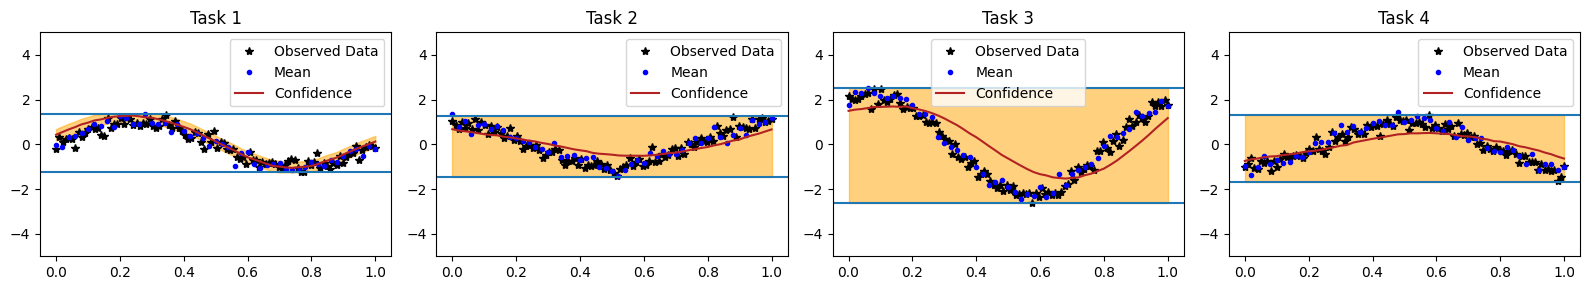

In [19]:
# Initialize plots
fig, axs = plt.subplots(1, num_tasks, figsize=(4 * num_tasks, 3))

ind = 0

for task, ax in enumerate(axs):
    # Plot training data as black stars
    ax.plot(train_x.detach().numpy(), train_y[:, task].detach().numpy(), 'k*')
    # Plot test data as red dots
    ax.plot(test_x.numpy(), test_y[:, task].numpy(), 'b.')
    # # Predictive mean as blue line
    ax.plot(test_x.squeeze(1).numpy(), mu[ind, :, task].numpy(), 'firebrick')
    # # Shade in confidence
    ax.fill_between(test_x.squeeze(1).numpy(), lower[ind, :, task].numpy(), upper[ind, :, task].numpy(), color='orange', alpha=0.5)
    ax.axhline(bounds[task,0])
    ax.axhline(bounds[task,1])
    ax.set_ylim([-5, 5])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])
    ax.set_title(f'Task {task + 1}')

fig.tight_layout()

plt.show()

In [18]:
test_x.numpy().shape, lower[ind,:,0].numpy().shape

((51, 1), (51,))